In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import sklearn


In [2]:
def ErrorMult2(sx,sy):
    dz=np.sqrt(dx**2+sy**2)
    return(sz)
    
def ErrorMult3(sx,sy,sz):
    dw=np.sqrt(sx**2 + sy**2 + sz**2)
    return(sw)

def ErrorMult4(sw,sx,sy,sz):
    da=np.sqrt(sw**2 + sx**2 + sy**2 + sz**2)
    return(da)

def ErrorAdd2(dx,dy):
    dw=np.sqrt(sx**2+sy**2)
    return(dw)

In [3]:
def ErrorEtch(masschange):
    
    #working in grams and m
    
    l=1.143*.025400 #length, in m
    w=.275*.025400 #width
    t=.009*.025400 #thick
    dens = 19280000 #g/m^3
    
    dw = .025400*.005
    dl = dw
    dt = .025400*.0005 #sample dimensions
    
    sw,sl,st = dw/w, dl/l, dt/t
    
    #equation for getting etch depth: change in m div by dens div by width and length, all div by 2
    
    masserror = (.2/1000)/masschange #masschange measurement rel error
    sd = .01 #dens rel error
    
    etch = 0.5* (masschange / dens) / (w*l) #got 1.43 for surface removed, josh got 1.37
    
    etcherror = ErrorMult4(masserror,sd,sw,sl)
    #For latest run, etch was 1.43 +- .396 um (prob mostly from thickness uncertainty)
    
    totaletch = etch*10**6
    totaletcherror = etcherror*etch*10**6*totaletch #microns
    
    print(f'Total etch is {totaletch} +- {totaletcherror} ')
    return(totaletch,totaletcherror)

In [4]:
etcherror1=ErrorEtch(4.6/1000)[1]
#etcherror2=ErrorEtch(5.2/1000)[1]
etcherror2=ErrorEtch(7/1000)[1]
etcherror3=ErrorEtch(9.97/1000)[1]
etcherror4=ErrorEtch(10.8/1000)[1]
etcherror5=ErrorEtch(11.2/1000)[1]

Total etch is 0.5882669492346044 +- 0.016740315902545214 
Total etch is 0.8951888357917893 +- 0.02851367399212611 
Total etch is 1.2750046704063058 +- 0.047454265397253156 
Total etch is 1.381148489507332 +- 0.05370583151239076 
Total etch is 1.4323021372668632 +- 0.05687444644628395 


In [5]:
temp1=np.float64([0.0001,10,20,30,40,50])
mag1=np.float64([0.0001,.59,.895,1.27,1.381,1.43])
temp1error=np.float64([0.0001,2/60,2/60,2/60,2/60,2/60]) #2 sec
mag1error=np.float64([0.0001,etcherror1,etcherror2,etcherror3,etcherror4,etcherror5]) #from error propagation, need to calc the lower 2!

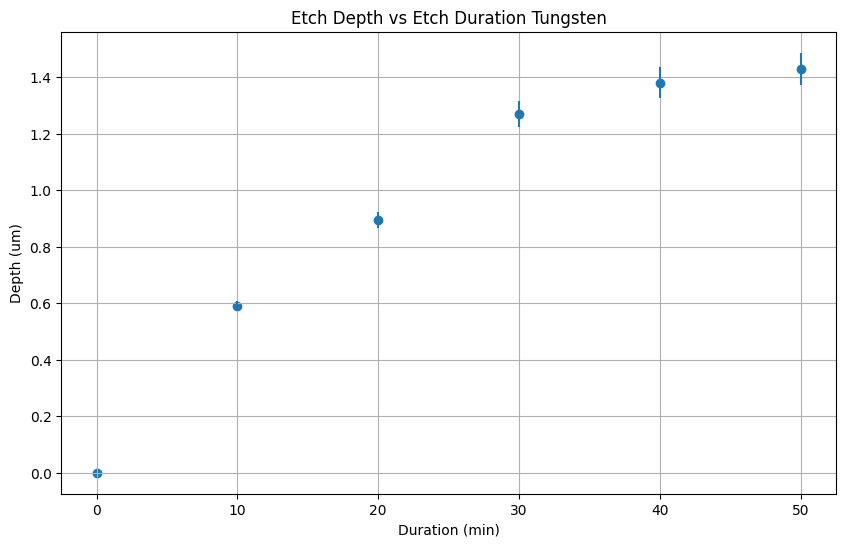

In [6]:
# Define plot space
fig, ax = plt.subplots(figsize=(10, 6))

# Define x and y axes
ax.scatter(temp1, 
        mag1)

# Set plot title and axes labels
ax.set(title = "Etch Depth vs Etch Duration Tungsten",
       xlabel = "Duration (min)",
       ylabel = "Depth (um)")

ax.errorbar(temp1, mag1, xerr=temp1error, yerr=mag1error, fmt='none')

ax.grid()

#plt.savefig('TbIG Both Demagnetization.png',dpi=100)
plt.savefig('Tungsten_Etching.png',dpi=100)

plt.show()

In [7]:
#np.delete(temp1,2)

Fitted parameters: A = -0.04341906316456811, B = 1.6525538867026188
 Need 21.40035716801105 min to get 1 micron
Chi square = 8.602648045035643, 4 d.o.f


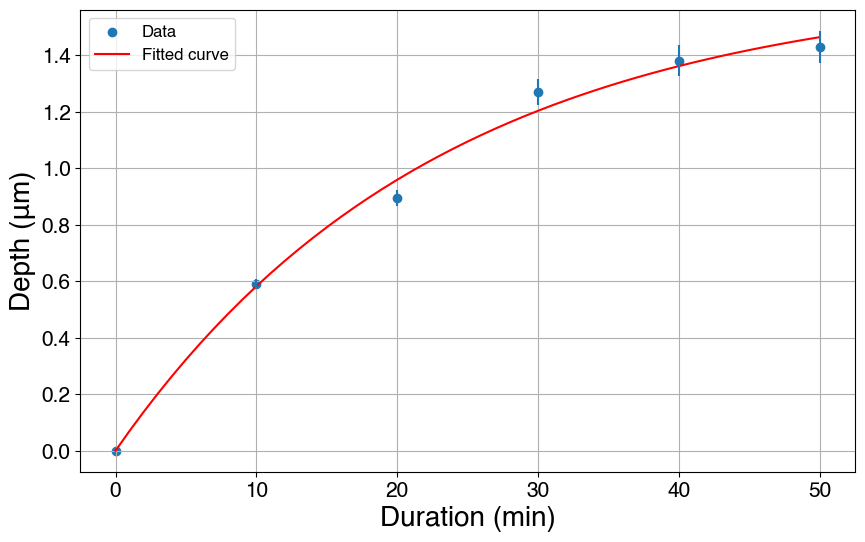

In [24]:
# Define plot space
fig, ax = plt.subplots(figsize=(10, 6))


SMALL_SIZE = 10
MEDIUM_SIZE = 12
BIGGER_SIZE = 15
huge=20

plt.rcParams.update({
    'font.size': huge,
    'axes.titlesize': huge,
    'axes.labelsize': huge,
    'xtick.labelsize': BIGGER_SIZE,
    'ytick.labelsize': BIGGER_SIZE,
    'legend.fontsize': MEDIUM_SIZE,
    'figure.titlesize': huge
})


# Define the function to fit
def model_function(x, A, B):
    return B * (1 - np.exp(A * x))

# Generate some example data
x_data = temp1
#x_data = temp1
A_true = -0.5  # Example true value for A
B_true = 2.0   # Example true value for B
y_data = mag1

# Use curve_fit to fit the model to the data
# Increase maxfev and adjust initial guesses
popt, pcov = curve_fit(model_function, x_data, y_data, p0=(-0.1, 1.0), maxfev=2000)

# Extract the fitting parameters
A_fit, B_fit = popt

print(f"Fitted parameters: A = {A_fit}, B = {B_fit}")
intercept=np.log(1-1/B_fit)/A_fit
print(f" Need {intercept} min to get 1 micron")


x=np.arange(0,51,1)

# Plot the original data and the fitted curve
plt.scatter(temp1, mag1, label='Data')
plt.plot(x, model_function(x, A_fit, B_fit), label='Fitted curve', color='red')
plt.legend()

y_pred = model_function(x_data, A_fit, B_fit)
sigma=mag1error
chi_square = np.sum(((y_data - y_pred) / sigma) ** 2)
print(f"Chi square = {chi_square}, 4 d.o.f")

#expfit=np.polyfit(temp1, np.log(mag1), 1)
#ax.plot(temp1, expfit[0]*temp1+expfit[1])

# Set plot title and axes labels
ax.set(
       xlabel = "Duration (min)",
       ylabel = "Depth (μm)")

ax.errorbar(temp1, mag1, xerr=temp1error, yerr=mag1error, fmt='none')

ax.grid()

#plt.savefig('TbIG Both Demagnetization.png',dpi=100)
plt.savefig('Tungsten_Etching_Exp_Fit.png',dpi=100)

plt.show()

In [25]:
import numpy as np
from scipy.odr import ODR, Model, RealData
import matplotlib.pyplot as plt

# Your original data and uncertainties
x = temp1  # Original x data
y = mag1  # Original y data
sigma_x = temp1error  # Uncertainties in x
sigma_y = mag1error  # Uncertainties in y

# Define the quadratic model function
def quadratic_model(p, x):
    a, b, c = p
    return a * x**2 + b * x + c

def linear_model(p,x):
    a, b = p
    return a * x + b 

def calculate_x_intercepts(a, b):
    root=(1-b)/a
    return(root)

# Create a Model object for the quadratic function
model = Model(linear_model)

# Number of Monte Carlo iterations
n_iterations = 10000

# Storage for fit parameters from each iteration (3 parameters: a, b, c)
fit_parameters = np.zeros((n_iterations, 2))

x_intercepts = []

for i in range(n_iterations):
    # Generate simulated data by adding random noise based on the uncertainties
    x_simulated = x + np.random.normal(0, sigma_x)
    y_simulated = y + np.random.normal(0, sigma_y)
    
    # Create a RealData object using the simulated data
    data = RealData(x_simulated, y_simulated, sx=sigma_x, sy=sigma_y)
    
    # Setup ODR with the model and simulated data
    odr = ODR(data, model, beta0=[1.0, 0.0])  # Initial guess for a, b, c
    
    # Run the regression
    out = odr.run()
    
    # Store the fit parameters
    fit_parameters[i, :] = out.beta
    
    # Calculate and store x-intercepts for this iteration
    intercepts = calculate_x_intercepts(*out.beta)
    #x_intercepts.extend(intercepts)  # This accumulates roots from all iterations

# Calculate the mean and standard deviation of the fit parameters
param_means = np.mean(fit_parameters, axis=0)
param_stds = np.std(fit_parameters, axis=0)

# Calculate the mean and standard deviation of the x-intercepts
if x_intercepts:  # Ensure there are intercepts to analyze
    mean_x_intercepts = np.mean(x_intercepts)
    std_x_intercepts = np.std(x_intercepts)
    print(f"X-intercept(s) Mean: {mean_x_intercepts}, Standard Deviation: {std_x_intercepts}")
else:
    print("No real x-intercepts found in any iteration.")

print(f"Parameter estimates (mean ± std): a = {param_means[0]} ± {param_stds[0]}, b = {param_means[1]} ± {param_stds[1]}")




No real x-intercepts found in any iteration.
Parameter estimates (mean ± std): a = 0.03928771785270338 ± 0.0006197017936940312, b = 0.00010225415315400003 ± 0.00010180871111570907


In [22]:
intercepts

27.346962599618013

In [26]:
# Parameters and their uncertainties
a, b = param_means
sigma_a, sigma_b = param_stds

# Monte Carlo simulation
n_samples = 10000
a_samples = np.random.normal(a, sigma_a, n_samples)
b_samples = np.random.normal(b, sigma_b, n_samples)

x_intercepts = []

for a_sample, b_sample in zip(a_samples, b_samples):
    x1 = (1-b_sample)/a_sample
    x_intercepts.append(x1)

# Estimate the uncertainty in the x-intercept
x_intercept_mean = np.mean(x_intercepts)
x_intercept_uncertainty = np.std(x_intercepts)

print(f"Estimated mean in the x-intercept: {x_intercept_mean}")
print(f"Estimated uncertainty in the x-intercept: {x_intercept_uncertainty}")


Estimated mean in the x-intercept: 25.464384837052243
Estimated uncertainty in the x-intercept: 0.4002358540324404


In [10]:
minbeta=param_means-param_stds
maxbeta=param_means+param_stds

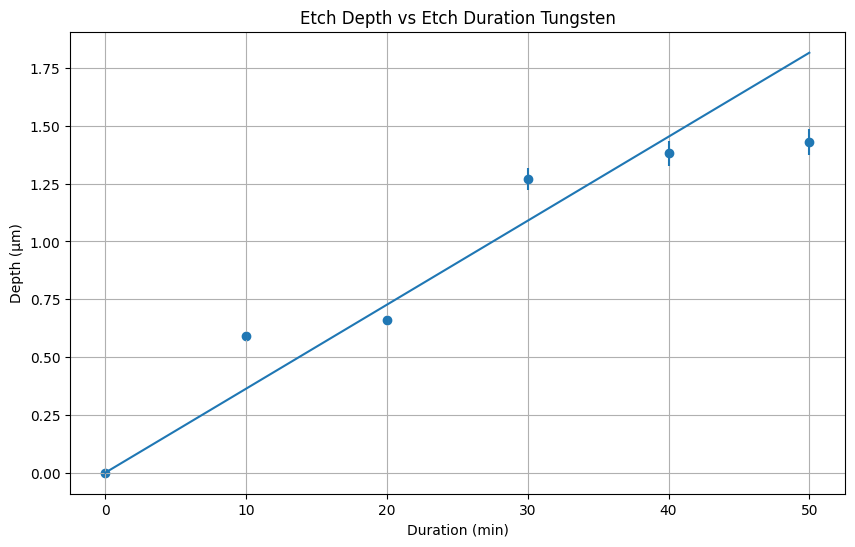

In [11]:
# Define plot space
fig, ax = plt.subplots(figsize=(10, 6))

# Define x and y axes
ax.scatter(temp1, 
        mag1)
#plt.plot(x,minbeta[0]*x+minbeta[1])
#plt.plot(x,maxbeta[0]*x+maxbeta[1])
plt.plot(x,param_means[0]*x+param_means[1])
# Set plot title and axes labels
ax.set(title = "Etch Depth vs Etch Duration Tungsten",
       xlabel = "Duration (min)",
       ylabel = "Depth (μm)")

ax.errorbar(temp1, mag1, xerr=temp1error, yerr=mag1error, fmt='none')

#newx=np.arange(0.1,50,.1)

#plt.plot(newx,.0748*np.log(newx) + 0.643)
#plt.plot(newx,.3*np.log(newx))

ax.grid()

plt.savefig('Tungsten_Etching_Fit.png',dpi=100)

plt.show()